<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Unified_Dark_Sector_Response_SPARC_KiDS_V4_CommonSourceProjection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Unified Dark-Sector Response — SPARC × KiDS V4 Common-Source Projection Test

**Purpose.** V3 forced SPARC and KiDS too close to one apparent kernel parameter. V4 tests the more physical ECSM idea:

```text
common ECSM burden/response source field
→ sector-specific projection
→ rotation-curve response
→ weak-lensing response
```

This mirrors the standard dark-matter comparison:

```text
dark mass density → gravitational potential → rotation curves + lensing
```

In ECSM the unifying object is not unseen particle mass, but a finite-response burden field. The sectors do **not** need identical apparent kernel exponents. They need a common source kernel that remains viable after each observable's projection geometry is allowed to distort the apparent response.

V4 therefore scans:

```text
K_source(s; p_source) = s^p / (1+s^p)
p_eff,SPARC = rho_dyn × p_source
p_eff,KiDS  = rho_opt × p_source
```

and uses a **normalised joint score** so the 3391-point SPARC table does not numerically swamp the 80-point KiDS table.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELL 00 — USER CONFIGURATION

SPARC_ZIP_CANDIDATES = [
    "/content/drive/MyDrive/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip",
    "/content/drive/MyDrive/ECSM_SPARC_data/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip",
    "/content/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip",
]

KIDS_ZIP_CANDIDATES = [
    "/content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip",
    "/content/drive/MyDrive/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip",
    "/content/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip",
]

OUTROOT = "/content/ecsm_unified_dark_sector_response_v4_common_source_projection_out"
DRIVE_COPY_DIR = "/content/drive/MyDrive/ECSM_Unified_Dark_Sector"
COPY_TO_DRIVE = True

import numpy as np
P_SOURCE_GRID = [round(x, 3) for x in np.arange(0.50, 2.501, 0.025)]
RHO_DYN_GRID  = [0.50, 0.625, 0.75, 0.875, 1.00, 1.125, 1.25, 1.375, 1.50, 1.75, 2.00]
RHO_OPT_GRID  = [0.50, 0.625, 0.75, 0.875, 1.00, 1.125, 1.25, 1.375, 1.50, 1.75, 2.00]
C_RBOUNDARY_GRID = [round(x, 3) for x in np.arange(0.50, 2.501, 0.025)]
Q_LENS_GRID = [round(x, 3) for x in np.arange(0.50, 2.501, 0.025)]

SPARC_DRIVER_CANDIDATES = ["chi", "B_boundary", "S_boundary", "B_basin", "S", "dchi_dlnR", "dloggbar_dlnR", "gbar"]
KIDS_DRIVER_CANDIDATES = [
    "combined_weighted_driver",
    "geometry_weighted_burden_driver",
    "domain_gradient_driver",
    "combined_number_driver",
    "combined_density_driver",
    "external_geometry_driver",
    "geometry_number_burden_driver",
    "geometry_density_burden_driver",
]

In [ ]:
# CELL 01 — SETUP / HELPERS

import os, json, zipfile, shutil, math, warnings
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=RuntimeWarning)

OUT = Path(OUTROOT); DATA = OUT / "data"; TAB = OUT / "tables"; FIG = OUT / "figures"
for p in [OUT, DATA, TAB, FIG]: p.mkdir(parents=True, exist_ok=True)

def banner(title):
    print("\n" + "="*72); print(title); print("="*72)

def first_existing(candidates):
    for p in candidates:
        if Path(p).exists(): return Path(p)
    return None

def extract_zip(zip_path, dest):
    dest = Path(dest); dest.mkdir(parents=True, exist_ok=True)
    print(f"Extracting: {zip_path}"); print(f"Size MB: {Path(zip_path).stat().st_size/1e6:.3f}")
    with zipfile.ZipFile(zip_path, "r") as z: z.extractall(dest)
    files = [p for p in dest.rglob("*") if p.is_file()]
    print("Extracted files:", len(files)); return files

def inventory_files(root, source):
    rows=[]; root=Path(root)
    for p in root.rglob("*"):
        if p.is_file():
            rows.append({"source":source,"path":str(p),"relative_path":str(p.relative_to(root)),"name":p.name,"suffix":p.suffix.lower(),"size_mb":p.stat().st_size/1e6})
    return pd.DataFrame(rows)

def find_file(inv, must_have, suffix=".csv"):
    df = inv[inv["suffix"].eq(suffix)].copy()
    for term in must_have: df = df[df["relative_path"].str.contains(term, case=False, regex=False)]
    if len(df)==0: return None
    return Path(df.sort_values("size_mb", ascending=False).iloc[0]["path"])

def safe_read_csv(path, **kw):
    if path is None or not Path(path).exists(): return pd.DataFrame()
    return pd.read_csv(path, **kw)

def clean_covariance_csv(path, n_expected=None):
    raw = pd.read_csv(path, header=None)
    arr = raw.apply(pd.to_numeric, errors="coerce").values
    if n_expected is not None:
        if arr.shape == (n_expected+1, n_expected): arr = arr[1:,:]
        if arr.shape == (n_expected, n_expected+1): arr = arr[:,1:]
        if arr.shape == (n_expected+1, n_expected+1): arr = arr[1:,1:]
    if np.isnan(arr[0]).any() and arr.shape[0] > 1: arr = arr[1:,:]
    if np.isnan(arr[:,0]).any() and arr.shape[1] > 1: arr = arr[:,1:]
    return np.asarray(arr, dtype=float)

def K_activation(s, p):
    s=np.clip(np.asarray(s,dtype=float), 1e-12, 1e12); p=float(p)
    return (s**p)/(1.0+s**p)

def fit_amplitude_unweighted(y, sigma, x, nonnegative=True):
    y=np.asarray(y,float); x=np.asarray(x,float); sigma=np.asarray(sigma,float)
    good=np.isfinite(y)&np.isfinite(x)&np.isfinite(sigma)&(sigma>0)
    if good.sum()<3: return np.nan, np.inf
    yw,xw=y[good]/sigma[good], x[good]/sigma[good]
    den=float(np.dot(xw,xw))
    if den<=0: return np.nan, np.inf
    A=float(np.dot(xw,yw)/den)
    if nonnegative: A=max(0.0,A)
    return A, float(np.sum((yw-A*xw)**2))

def fit_amplitude_cov(y, x, cov, nonnegative=True):
    y=np.asarray(y,float); x=np.asarray(x,float); cov=np.asarray(cov,float)
    try:
        L=np.linalg.cholesky(cov + np.eye(cov.shape[0])*1e-18)
        yw=np.linalg.solve(L,y); xw=np.linalg.solve(L,x); method="cholesky"
        den=float(np.dot(xw,xw))
        if den<=0: return np.nan,np.inf,method
        A=float(np.dot(xw,yw)/den)
        if nonnegative: A=max(0.0,A)
        return A, float(np.sum((yw-A*xw)**2)), method
    except Exception:
        inv=np.linalg.pinv(cov); den=float(x@inv@x)
        if den<=0: return np.nan,np.inf,"pinv_failed"
        A=float((x@inv@y)/den)
        if nonnegative: A=max(0.0,A)
        r=y-A*x
        return A, float(r@inv@r), "pinv"

def sector_weight(delta_chi2, N, temperature=1.0):
    if not np.isfinite(delta_chi2): return 0.0
    return float(np.exp(-0.5*max(0.0,delta_chi2)/max(1,int(N))/temperature))

def save_json(obj, path):
    path=Path(path)
    with open(path,"w") as f: json.dump(obj,f,indent=2)
    print("Saved:", path)

In [ ]:
# CELL 02 — EXTRACT PACKAGES AND LOCATE TABLES

banner("CELL 02 — EXTRACT PACKAGES AND LOCATE TABLES")
sparc_zip = first_existing(SPARC_ZIP_CANDIDATES); kids_zip = first_existing(KIDS_ZIP_CANDIDATES)
print("SPARC ZIP:", sparc_zip); print("KiDS ZIP:", kids_zip)
if sparc_zip is None: raise FileNotFoundError("No SPARC ZIP found. Update SPARC_ZIP_CANDIDATES in CELL 00.")
if kids_zip is None: raise FileNotFoundError("No KiDS ZIP found. Update KIDS_ZIP_CANDIDATES in CELL 00.")
extract_zip(sparc_zip, DATA/"sparc_v3_extracted"); extract_zip(kids_zip, DATA/"kids_v12_extracted")
inv=pd.concat([inventory_files(DATA/"sparc_v3_extracted","sparc"), inventory_files(DATA/"kids_v12_extracted","kids")], ignore_index=True)
display(inv.head(30)); inv.to_csv(TAB/"v4_input_inventory.csv", index=False)
sparc_inv=inv[inv.source.eq("sparc")].copy(); kids_inv=inv[inv.source.eq("kids")].copy()
selected={
 "kids_pnee_drivers": find_file(kids_inv,["v12_kids_pnee_with_real_2dflens_drivers"]),
 "kids_covariance": find_file(kids_inv,["v12_kids_pnee_covariance"]),
 "kids_full_competition": find_file(kids_inv,["v12_full_data_model_competition_real_2dflens"]),
 "kids_source_holdout": find_file(kids_inv,["v12_heldout_source_bin_summary_real_2dflens"]),
 "kids_lens_holdout": find_file(kids_inv,["v12_heldout_lens_bin_summary_real_2dflens"]),
 "sparc_curves": find_file(sparc_inv,["v3_boundary_gradient_attractor_curves"]),
 "sparc_summary": find_file(sparc_inv,["v3_boundary_gradient_attractor_summary"]),
 "sparc_metrics": find_file(sparc_inv,["v3_boundary_attractor_metrics_summary"]),
}
for k,v in selected.items(): print(k,"->",v)
missing=[k for k,v in selected.items() if v is None and k in ["kids_pnee_drivers","kids_covariance","sparc_curves"]]
if missing: raise FileNotFoundError(f"Missing required tables: {missing}")
save_json({k:str(v) if v is not None else None for k,v in selected.items()}, TAB/"v4_selected_input_paths.json")


CELL 02 — EXTRACT PACKAGES AND LOCATE TABLES
SPARC ZIP: /content/drive/MyDrive/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip
KiDS ZIP: /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip
Extracting: /content/drive/MyDrive/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip
Size MB: 1.099
Extracted files: 19
Extracting: /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outputs.zip
Size MB: 294.461
Extracted files: 4391


,source,path,relative_path,name,suffix,size_mb
0,sparc,/content/ecsm_unified_dark_sector_response_v4_...,v3_boundary_gradient_attractor_evidence_note.txt,v3_boundary_gradient_attractor_evidence_note.txt,.txt,0.000834
1,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_cv_fold_5_detail.csv,v3_cv_fold_5_detail.csv,.csv,0.001833
2,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_parse_failures.csv,v3_parse_failures.csv,.csv,0.000001
3,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_boundary_gradient_attractor_curves.csv,v3_boundary_gradient_attractor_curves.csv,.csv,0.961066
4,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_boundary_gradient_attractor_summary.csv,v3_boundary_gradient_attractor_summary.csv,.csv,0.032243
5,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_cv_fold_4_detail.csv,v3_cv_fold_4_detail.csv,.csv,0.001845
6,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_boundary_attractor_metrics_summary.csv,v3_boundary_attractor_metrics_summary.csv,.csv,0.000340
7,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_raw_point_table.csv,v3_raw_point_table.csv,.csv,0.171678
8,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_cv_fold_2_detail.csv,v3_cv_fold_2_detail.csv,.csv,0.001824
9,sparc,/content/ecsm_unified_dark_sector_response_v4_...,data/v3_cv_fold_1_detail.csv,v3_cv_fold_1_detail.csv,.csv,0.001838


kids_pnee_drivers -> /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/data/kids_v12_extracted/tables/v12_kids_pnee_with_real_2dflens_drivers.csv
kids_covariance -> /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/data/kids_v12_extracted/tables/v12_kids_pnee_covariance.csv
kids_full_competition -> /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/data/kids_v12_extracted/tables/v12_full_data_model_competition_real_2dflens.csv
kids_source_holdout -> /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/data/kids_v12_extracted/tables/v12_heldout_source_bin_summary_real_2dflens.csv
kids_lens_holdout -> /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/data/kids_v12_extracted/tables/v12_heldout_lens_bin_summary_real_2dflens.csv
sparc_curves -> /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/data/sparc_v3_extracted/data/v3_boundary_gradient_attr


CELL 03 — SHARED COMMON-SOURCE KERNEL VISUALISATION


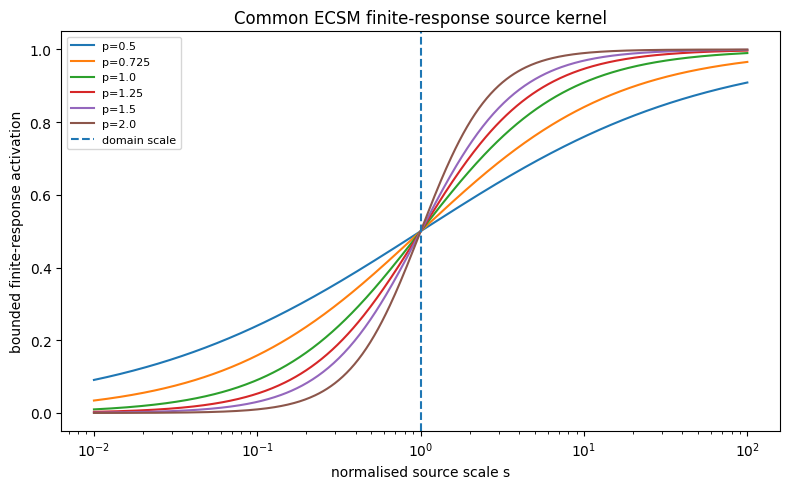

p_eff,SPARC = rho_dyn × p_source
p_eff,KiDS  = rho_opt × p_source


In [ ]:
# CELL 03 — SHARED COMMON-SOURCE KERNEL VISUALISATION

banner("CELL 03 — SHARED COMMON-SOURCE KERNEL VISUALISATION")
s=np.logspace(-2,2,500)
plt.figure(figsize=(8,5))
for p in [0.5,0.725,1.0,1.25,1.5,2.0]: plt.plot(s,K_activation(s,p),label=f"p={p}")
plt.axvline(1.0,ls="--",label="domain scale"); plt.xscale("log")
plt.xlabel("normalised source scale s"); plt.ylabel("bounded finite-response activation")
plt.title("Common ECSM finite-response source kernel"); plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(FIG/"v4_common_source_kernel_family.png",dpi=180); plt.show()
print("p_eff,SPARC = rho_dyn × p_source")
print("p_eff,KiDS  = rho_opt × p_source")

In [ ]:
# CELL 04 — LOAD KiDS AND SPARC DATA

banner("CELL 04 — LOAD KiDS AND SPARC DATA")
kids=safe_read_csv(selected["kids_pnee_drivers"]).copy()
kids["lens_bin"]=kids["lens_bin"].astype(int); kids["source_bin"]=kids["source_bin"].astype(int); kids["ell_bin"]=kids["ell_bin"].astype(int)
kids=kids.sort_values("vec_index" if "vec_index" in kids.columns else ["lens_bin","source_bin","ell_bin"]).reset_index(drop=True)
cov=clean_covariance_csv(selected["kids_covariance"], n_expected=len(kids))
if cov.shape != (len(kids),len(kids)): raise ValueError(f"KiDS covariance mismatch: kids={len(kids)}, cov={cov.shape}")
kids_full=safe_read_csv(selected["kids_full_competition"]); kids_source_hold=safe_read_csv(selected["kids_source_holdout"]); kids_lens_hold=safe_read_csv(selected["kids_lens_holdout"])
sparc=safe_read_csv(selected["sparc_curves"]); sparc_summary=safe_read_csv(selected["sparc_summary"]); sparc_metrics=safe_read_csv(selected["sparc_metrics"])
for col in ["Rad","Vobs","errV","Vbar","R_boundary"]:
    if col not in sparc.columns: raise KeyError(f"SPARC table missing required column: {col}")
sparc=sparc.replace([np.inf,-np.inf],np.nan).dropna(subset=["galaxy","Rad","Vobs","errV","Vbar","R_boundary"])
sparc=sparc[(sparc.errV>0)&(sparc.Vobs>0)&(sparc.Vbar>=0)&(sparc.Rad>0)&(sparc.R_boundary>0)].copy(); sparc["galaxy"]=sparc["galaxy"].astype(str)
available_sparc_drivers=[d for d in SPARC_DRIVER_CANDIDATES if d in sparc.columns]
available_kids_drivers=[d for d in KIDS_DRIVER_CANDIDATES if d in kids.columns]
print("KiDS rows:",len(kids),"cov:",cov.shape,"drivers:",available_kids_drivers); display(kids.head())
print("SPARC rows:",len(sparc),"galaxies:",sparc.galaxy.nunique(),"drivers:",available_sparc_drivers); display(sparc.head())
if not available_sparc_drivers: raise ValueError("No SPARC driver columns found.")
if not available_kids_drivers: raise ValueError("No KiDS driver columns found.")


CELL 04 — LOAD KiDS AND SPARC DATA
KiDS rows: 80 cov: (80, 80) drivers: ['combined_weighted_driver', 'geometry_weighted_burden_driver', 'domain_gradient_driver', 'combined_number_driver', 'combined_density_driver', 'external_geometry_driver', 'geometry_number_burden_driver', 'geometry_density_burden_driver']


,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple,...,domain_boundary_gradient_raw,domain_boundary_gradient_chi,external_geometry_driver,geometry_weighted_burden_driver,geometry_density_burden_driver,geometry_number_burden_driver,domain_gradient_driver,combined_weighted_driver,combined_density_driver,combined_number_driver
0,1,1,1,-0.001093,118.441992,0,0.000557,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725
1,1,1,2,-0.000132,166.156414,1,0.000715,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725
2,1,1,3,-0.000616,233.092617,2,0.000883,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725
3,1,1,4,0.001383,326.994107,3,0.001125,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725
4,1,1,5,0.001706,458.723863,4,0.001475,0.2,0.5,0.35,...,0.0,0.0,0.047336,0.041923,0.051964,0.048725,0.0,0.041923,0.051964,0.048725


SPARC rows: 3391 galaxies: 175 drivers: ['chi', 'B_boundary', 'S_boundary', 'B_basin', 'S', 'dchi_dlnR', 'dloggbar_dlnR', 'gbar']


,galaxy,Rad,Vobs,errV,Vgas,Vdisk,Vbul,SBdisk,SBbul,Vbar,...,Vboundary,gbar,chi,dchi_dlnR,dloggbar_dlnR,B_boundary,B_basin,S,S_boundary,R_boundary
0,CamB,0.16,1.99,1.5,1.86,3.75,0.0,30.32,0.0,3.238958,...,3.239213,2.124908e-12,0.979193,-0.020152,0.901988,0.082082,0.000000,0.000062,0.000031,1.79
1,CamB,0.41,4.84,1.5,4.24,9.47,0.0,23.77,0.0,7.925784,...,8.114373,4.965352e-12,0.960230,-0.031924,0.552320,0.211609,0.025522,0.004652,0.014990,1.79
2,CamB,0.57,6.79,1.5,5.61,11.76,0.0,15.87,0.0,10.030997,...,10.554730,5.720879e-12,0.948354,-0.026016,0.374886,0.130187,0.018210,0.054309,0.036095,1.79
3,CamB,0.73,8.87,1.5,6.77,13.72,0.0,12.40,0.0,11.830135,...,14.302680,6.213067e-12,0.943781,-0.008304,0.112838,0.000000,0.015961,0.311129,0.162892,1.79
4,CamB,0.90,10.90,1.5,7.77,14.80,0.0,9.63,0.0,13.034297,...,19.185871,6.117615e-12,0.943846,0.011439,-0.257994,0.039303,0.115771,0.724652,0.408049,1.79



CELL 05 — KiDS FAST LOCAL SHARED-p RESCAN FOR V4
Covariance method: cholesky


,sector,driver,p_shared,q1,q2,ellB_lens1,ellB_lens2,A,chi2,smooth_chi2,delta_chi2_vs_smooth,fractional_improvement_vs_smooth,N,AIC,BIC
0,KiDS,combined_weighted_driver,1.45,2.25,1.975,1000.0,875.0,0.038781,167.940978,811.72596,643.784983,0.793106,80,175.940978,185.469084
1,KiDS,combined_weighted_driver,1.45,2.25,1.975,1000.0,900.0,0.038981,168.073688,811.72596,643.652273,0.792943,80,176.073688,185.601794
2,KiDS,combined_weighted_driver,1.45,2.25,1.975,1000.0,850.0,0.038565,168.141528,811.72596,643.584432,0.792859,80,176.141528,185.669635
3,KiDS,combined_weighted_driver,1.50,2.25,1.975,1000.0,875.0,0.039530,168.260741,811.72596,643.465219,0.792712,80,176.260741,185.788848
4,KiDS,combined_weighted_driver,1.50,2.25,1.975,1000.0,900.0,0.039740,168.406108,811.72596,643.319853,0.792533,80,176.406108,185.934214
5,KiDS,combined_weighted_driver,1.50,2.25,1.975,1000.0,850.0,0.039303,168.465068,811.72596,643.260892,0.792461,80,176.465068,185.993174
6,KiDS,combined_weighted_driver,1.45,2.25,1.975,1000.0,825.0,0.038332,168.712150,811.72596,643.013810,0.792156,80,176.712150,186.240257
7,KiDS,combined_weighted_driver,1.40,2.25,1.975,1000.0,875.0,0.037988,168.863100,811.72596,642.862860,0.791970,80,176.863100,186.391207
8,KiDS,combined_weighted_driver,1.40,2.25,1.975,1000.0,900.0,0.038177,168.986913,811.72596,642.739048,0.791818,80,176.986913,186.515019
9,KiDS,combined_weighted_driver,1.40,2.25,1.975,1000.0,850.0,0.037783,169.055414,811.72596,642.670546,0.791733,80,177.055414,186.583521


Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_kids_fast_local_shared_p_rescan.csv
Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_best_kids_fast_local_shared_p_model.json
Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_kids_fast_local_best_prediction.csv


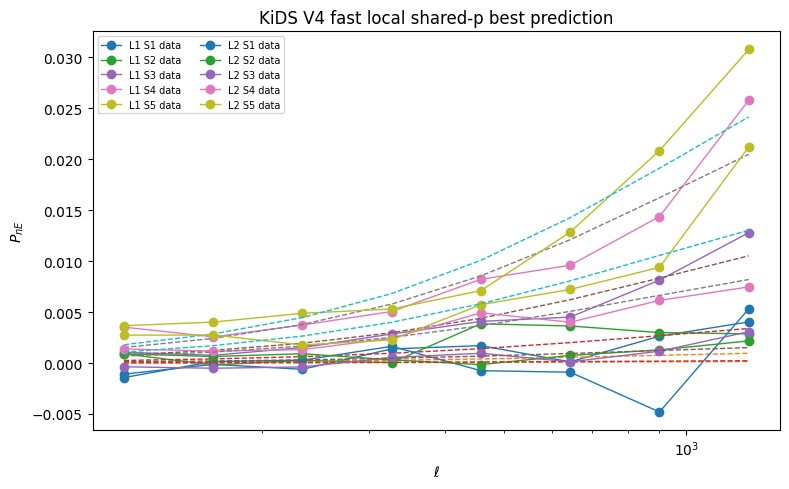

Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/figures/v4_kids_fast_local_shared_p_best_prediction.png

Best KiDS fast local shared-p model:
{
  "sector": "KiDS",
  "driver": "combined_weighted_driver",
  "p_shared": 1.45,
  "q1": 2.25,
  "q2": 1.975,
  "ellB_lens1": 1000.0,
  "ellB_lens2": 875.0,
  "A": 0.038780961087312604,
  "chi2": 167.94097763212562,
  "smooth_chi2": 811.7259604367568,
  "delta_chi2_vs_smooth": 643.7849828046312,
  "fractional_improvement_vs_smooth": 0.7931063119605496,
  "N": 80,
  "AIC": 175.94097763212562,
  "BIC": 185.46908417082113
}


In [ ]:
# CELL 05 — KiDS FAST LOCAL SHARED-p RESCAN FOR V4
banner("CELL 05 — KiDS FAST LOCAL SHARED-p RESCAN FOR V4")

import numpy as np
import pandas as pd
import json
from pathlib import Path

# ---------------------------------------------------------------------
# Output folders
# ---------------------------------------------------------------------
TAB.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Configuration: fast local KiDS scan
# ---------------------------------------------------------------------
KIDS_DRIVER = "combined_weighted_driver"

# Fast grid centred around the V3/V4 region.
# This avoids the huge full scan while still testing whether KiDS sits
# near the same finite-response family.
p_grid_fast = np.round(np.arange(1.20, 1.81, 0.05), 3)

ellB1_grid_fast = np.round(np.linspace(700, 1000, 13), 6)
ellB2_grid_fast = np.round(np.linspace(600, 900, 13), 6)

# Keep the q exponents locally frozen from the V3 best KiDS branch.
q1_grid_fast = [2.25]
q2_grid_fast = [1.975]

rows = []

# ---------------------------------------------------------------------
# Required KiDS arrays
# ---------------------------------------------------------------------
if "kids" not in globals():
    raise NameError("kids is not loaded. Re-run Cell 04 first.")

required_cols = ["Pgk_E", "ell", "lens_bin", KIDS_DRIVER]
missing = [c for c in required_cols if c not in kids.columns]
if missing:
    raise KeyError(f"KiDS table missing required columns: {missing}")

y = kids["Pgk_E"].values.astype(float)
driver = kids[KIDS_DRIVER].values.astype(float)
ell = kids["ell"].values.astype(float)
lens_bin = kids["lens_bin"].values.astype(int)

# ---------------------------------------------------------------------
# Covariance / inverse covariance
# ---------------------------------------------------------------------
if "cov" not in globals():
    if "PATHS" in globals() and "kids_covariance" in PATHS:
        cov = pd.read_csv(PATHS["kids_covariance"]).values.astype(float)
        print("Loaded covariance from:", PATHS["kids_covariance"])
    else:
        raise NameError("cov is not loaded and PATHS['kids_covariance'] is unavailable.")

# Defensive cleanup in case a CSV header row sneaks in again.
cov = np.asarray(cov, dtype=float)
if cov.shape[0] != cov.shape[1]:
    if cov.shape[0] == cov.shape[1] + 1:
        print("Detected extra covariance header row; dropping first row.")
        cov = cov[1:, :]
    elif cov.shape[1] == cov.shape[0] + 1:
        print("Detected extra covariance header column; dropping first column.")
        cov = cov[:, 1:]
    else:
        raise ValueError(f"Unexpected covariance shape: {cov.shape}")

if cov.shape[0] != len(kids):
    raise ValueError(f"KiDS/covariance mismatch: N={len(kids)}, cov={cov.shape}")

# Stable inverse covariance
jitter = 0.0
try:
    L = np.linalg.cholesky(cov)
    cov_inv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(len(cov))))
    cov_method = "cholesky"
except np.linalg.LinAlgError:
    jitter = float(np.nanmedian(np.diag(cov)) * 1e-8)
    cov_j = cov + np.eye(len(cov)) * jitter
    L = np.linalg.cholesky(cov_j)
    cov_inv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(len(cov_j))))
    cov_method = f"cholesky+jitter({jitter:.3e})"

print("Covariance method:", cov_method)

# ---------------------------------------------------------------------
# Smooth reference chi2
# ---------------------------------------------------------------------
if "kids_full_competition" not in globals():
    if "PATHS" in globals() and "kids_full_competition" in PATHS:
        kids_full_competition = pd.read_csv(PATHS["kids_full_competition"])
        print("Loaded kids_full_competition from:", PATHS["kids_full_competition"])
    else:
        kids_full_competition = None

if kids_full_competition is not None:
    smooth_rows = kids_full_competition[
        kids_full_competition.get("model", pd.Series(dtype=str)).astype(str).str.contains("smooth", case=False, na=False) |
        kids_full_competition.get("family", pd.Series(dtype=str)).astype(str).str.contains("smooth", case=False, na=False)
    ]

    if len(smooth_rows) > 0:
        smooth_chi2 = float(smooth_rows.iloc[0]["chi2"])
    else:
        smooth_chi2 = 811.7259604367568
        print("WARNING: smooth row not found; using known V12 smooth chi2:", smooth_chi2)
else:
    smooth_chi2 = 811.7259604367568
    print("WARNING: kids_full_competition not available; using known V12 smooth chi2:", smooth_chi2)

# ---------------------------------------------------------------------
# Shared finite-response kernel and fit helpers
# ---------------------------------------------------------------------
def K_finite_response(x, p):
    """
    Bounded ECSM finite-response kernel:
        K(s;p) = s^p / (1 + s^p)
    """
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 1e-30, np.inf)
    return (x ** p) / (1.0 + x ** p)


def chi2_from_template(template, y, cov_inv):
    """
    Fit one amplitude A for y ≈ A template under full covariance.
    """
    t = np.asarray(template, dtype=float)
    yv = np.asarray(y, dtype=float)

    denom = float(t @ cov_inv @ t)
    if not np.isfinite(denom) or denom <= 0:
        return np.nan, np.nan, None

    A = float((t @ cov_inv @ yv) / denom)
    pred = A * t
    resid = yv - pred
    chi2 = float(resid @ cov_inv @ resid)
    return A, chi2, pred


# ---------------------------------------------------------------------
# Fast local scan
# ---------------------------------------------------------------------
best_pred = None

for p_shared in p_grid_fast:
    for q1 in q1_grid_fast:
        for q2 in q2_grid_fast:
            for ellB1 in ellB1_grid_fast:
                for ellB2 in ellB2_grid_fast:

                    ellB = np.where(lens_bin == 1, ellB1, ellB2)
                    q = np.where(lens_bin == 1, q1, q2)

                    # KiDS angular response:
                    # driver × finite-response ell activation
                    s = ell / ellB
                    kernel = K_finite_response(s, p_shared)

                    template = driver * kernel

                    A, chi2, pred = chi2_from_template(template, y, cov_inv)

                    if not np.isfinite(chi2):
                        continue

                    rows.append({
                        "sector": "KiDS",
                        "driver": KIDS_DRIVER,
                        "p_shared": float(p_shared),
                        "q1": float(q1),
                        "q2": float(q2),
                        "ellB_lens1": float(ellB1),
                        "ellB_lens2": float(ellB2),
                        "A": float(A),
                        "chi2": float(chi2),
                        "smooth_chi2": float(smooth_chi2),
                        "delta_chi2_vs_smooth": float(smooth_chi2 - chi2),
                        "fractional_improvement_vs_smooth": float((smooth_chi2 - chi2) / smooth_chi2),
                        "N": int(len(y)),
                        "AIC": float(chi2 + 2 * 4),
                        "BIC": float(chi2 + np.log(len(y)) * 4),
                    })

                    if best_pred is None or chi2 < best_pred["chi2"]:
                        best_pred = {
                            "p_shared": float(p_shared),
                            "q1": float(q1),
                            "q2": float(q2),
                            "ellB_lens1": float(ellB1),
                            "ellB_lens2": float(ellB2),
                            "A": float(A),
                            "chi2": float(chi2),
                            "pred": pred,
                            "template": template,
                            "kernel": kernel,
                        }

kids_fast = pd.DataFrame(rows).sort_values("chi2").reset_index(drop=True)

if len(kids_fast) == 0:
    raise RuntimeError("KiDS fast scan returned no valid rows.")

display(kids_fast.head(30))

# ---------------------------------------------------------------------
# Save scan products
# ---------------------------------------------------------------------
kids_fast_path = TAB / "v4_kids_fast_local_shared_p_rescan.csv"
kids_fast.to_csv(kids_fast_path, index=False)
print("Saved:", kids_fast_path)

best_kids_fast = kids_fast.iloc[0].to_dict()

best_json_path = TAB / "v4_best_kids_fast_local_shared_p_model.json"
with open(best_json_path, "w") as f:
    json.dump(best_kids_fast, f, indent=2)
print("Saved:", best_json_path)

# Prediction table for best model
pred_table = kids.copy()
pred_table["kids_fast_best_pred"] = best_pred["pred"]
pred_table["kids_fast_best_resid"] = pred_table["Pgk_E"] - pred_table["kids_fast_best_pred"]
pred_table["kids_fast_best_kernel"] = best_pred["kernel"]
pred_table["kids_fast_best_template"] = best_pred["template"]

pred_path = TAB / "v4_kids_fast_local_best_prediction.csv"
pred_table.to_csv(pred_path, index=False)
print("Saved:", pred_path)

# ---------------------------------------------------------------------
# Diagnostic figure
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for (lb, sb), g in pred_table.groupby(["lens_bin", "source_bin"]):
    g = g.sort_values("ell")
    ax.plot(g["ell"], g["Pgk_E"], marker="o", linewidth=1, label=f"L{lb} S{sb} data")
    ax.plot(g["ell"], g["kids_fast_best_pred"], linestyle="--", linewidth=1)

ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$P_{nE}$")
ax.set_title("KiDS V4 fast local shared-p best prediction")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()

fig_path = FIG / "v4_kids_fast_local_shared_p_best_prediction.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

print("\nBest KiDS fast local shared-p model:")
print(json.dumps(best_kids_fast, indent=2))


CELL 06 — SPARC FAST LOCAL COMMON-SOURCE RESCAN FOR V4
SPARC fast rows: 3391 galaxies: 175
Drivers: ['chi', 'B_boundary', 'S_boundary', 'B_basin']
SPARC Vbar baseline chi2: 1555172.3235320644


,sector,driver,driver_mode,p_source,rho_dyn,p_eff,c_Rboundary,A,chi2,baseline_chi2,delta_chi2_vs_Vbar,fractional_improvement_vs_Vbar,N,N_galaxies,AIC,BIC
0,SPARC,chi,positive_normalised,1.55,0.45,0.6975,2.5,4.083333,216052.920134,1.555172e+06,1.339119e+06,0.861075,3391,175,216062.920134,216093.564535
1,SPARC,chi,positive_normalised,1.40,0.50,0.7000,2.5,4.083333,216053.611609,1.555172e+06,1.339119e+06,0.861074,3391,175,216063.611609,216094.256009
2,SPARC,chi,positive_normalised,0.70,1.00,0.7000,2.5,4.083333,216053.611609,1.555172e+06,1.339119e+06,0.861074,3391,175,216063.611609,216094.256009
3,SPARC,chi,positive_normalised,1.00,0.70,0.7000,2.5,4.083333,216053.611609,1.555172e+06,1.339119e+06,0.861074,3391,175,216063.611609,216094.256009
4,SPARC,chi,positive_normalised,1.15,0.60,0.6900,2.5,4.083333,216061.687399,1.555172e+06,1.339111e+06,0.861069,3391,175,216071.687399,216102.331800
5,SPARC,chi,positive_normalised,0.60,1.15,0.6900,2.5,4.083333,216061.687399,1.555172e+06,1.339111e+06,0.861069,3391,175,216071.687399,216102.331800
6,SPARC,chi,positive_normalised,1.25,0.55,0.6875,2.5,4.083333,216068.244597,1.555172e+06,1.339104e+06,0.861065,3391,175,216078.244597,216108.888998
7,SPARC,chi,positive_normalised,1.40,0.50,0.7000,2.5,4.125000,216076.913588,1.555172e+06,1.339095e+06,0.861059,3391,175,216086.913588,216117.557989
8,SPARC,chi,positive_normalised,1.00,0.70,0.7000,2.5,4.125000,216076.913588,1.555172e+06,1.339095e+06,0.861059,3391,175,216086.913588,216117.557989
9,SPARC,chi,positive_normalised,0.70,1.00,0.7000,2.5,4.125000,216076.913588,1.555172e+06,1.339095e+06,0.861059,3391,175,216086.913588,216117.557989


Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_sparc_fast_common_source_rescan.csv
Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_best_sparc_fast_common_source_model.json
Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_sparc_fast_common_source_best_prediction.csv
Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_sparc_common_source_projection_summary.json

Best SPARC fast common-source model:
{
  "sector": "SPARC",
  "driver": "chi",
  "driver_mode": "positive_normalised",
  "p_source": 1.55,
  "rho_dyn": 0.45,
  "p_eff": 0.6975,
  "c_Rboundary": 2.5,
  "A": 4.083333333333333,
  "chi2": 216052.9201340112,
  "baseline_chi2": 1555172.3235320644,
  "delta_chi2_vs_Vbar": 1339119.4033980533,
  "fractional_improvement_vs_Vbar": 0.8610746109194396,
  "N": 3391,
  "N_galaxies": 175,
  "AIC": 216062.9201340112,
  "BIC": 2

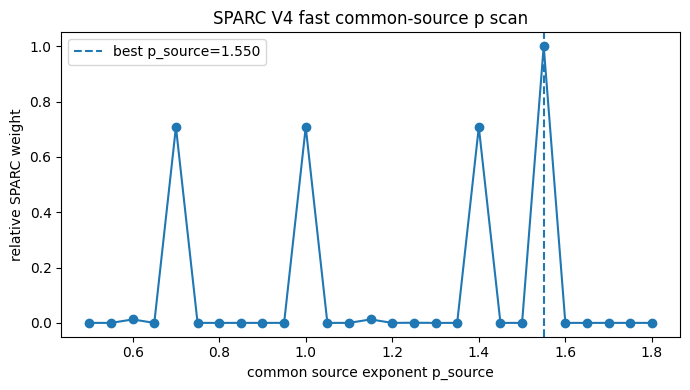

Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/figures/v4_sparc_fast_common_source_p_curve.png


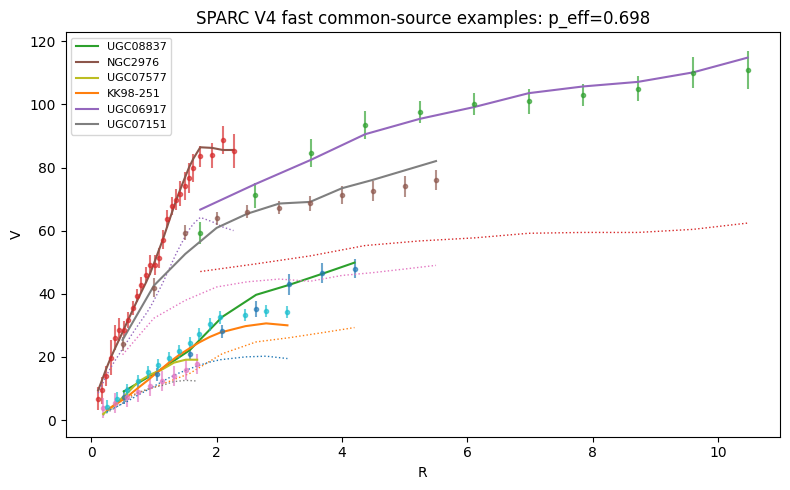

Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/figures/v4_sparc_fast_common_source_example_fits.png


In [ ]:
# CELL 06 — SPARC FAST LOCAL COMMON-SOURCE RESCAN FOR V4
banner("CELL 06 — SPARC FAST LOCAL COMMON-SOURCE RESCAN FOR V4")

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

TAB.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Required SPARC table
# ---------------------------------------------------------------------
if "sparc" not in globals():
    raise NameError("sparc is not loaded. Re-run Cell 04 first.")

required = ["galaxy", "Rad", "Vobs", "errV", "Vbar", "R_boundary"]
missing = [c for c in required if c not in sparc.columns]
if missing:
    raise KeyError(f"SPARC table missing required columns: {missing}")

# ---------------------------------------------------------------------
# Fast local V4 configuration
# ---------------------------------------------------------------------
# Keep the scan deliberately small. This is V4 fast mode, not the full V3 brute force.
SPARC_DRIVERS = ["chi", "B_boundary", "S_boundary", "B_basin"]

SPARC_DRIVERS = [d for d in SPARC_DRIVERS if d in sparc.columns]
if not SPARC_DRIVERS:
    raise KeyError("No usable SPARC drivers found.")

# V3 direct best was around p_eff ~ 0.70–0.725.
# V4 is testing projection: p_eff = rho_dyn × p_source.
p_source_grid = np.round(np.arange(0.50, 1.81, 0.05), 3)

# dynamical projection factor: how strongly the common source kernel projects into rotation curves
rho_dyn_grid = np.round(np.arange(0.45, 1.16, 0.05), 3)

# radial source scale relative to detected/domain boundary
c_Rboundary_grid = np.round(np.arange(1.50, 2.51, 0.10), 3)

# amplitude grid for velocity-squared response
A_grid = np.linspace(0.0, 5.0, 121)

# Optional cap for speed. Uses all points by default.
MAX_POINTS = None

work = sparc.copy()

for c in ["Rad", "Vobs", "errV", "Vbar", "R_boundary"]:
    work[c] = pd.to_numeric(work[c], errors="coerce")

for d in SPARC_DRIVERS:
    work[d] = pd.to_numeric(work[d], errors="coerce")

work = work.replace([np.inf, -np.inf], np.nan)
work = work.dropna(subset=["galaxy", "Rad", "Vobs", "errV", "Vbar", "R_boundary"] + SPARC_DRIVERS)
work = work[(work["errV"] > 0) & (work["Rad"] > 0) & (work["R_boundary"] > 0)]

if MAX_POINTS is not None and len(work) > MAX_POINTS:
    work = work.sample(MAX_POINTS, random_state=12345).sort_values(["galaxy", "Rad"])

print("SPARC fast rows:", len(work), "galaxies:", work["galaxy"].nunique())
print("Drivers:", SPARC_DRIVERS)

# ---------------------------------------------------------------------
# Kernel and chi2 helpers
# ---------------------------------------------------------------------
def K_finite_response(s, p):
    s = np.asarray(s, dtype=float)
    s = np.clip(s, 1e-30, np.inf)
    return (s ** p) / (1.0 + s ** p)


def chi2_velocity_model(v_model, v_obs, err):
    resid = (v_obs - v_model) / err
    return float(np.sum(resid ** 2))


vobs = work["Vobs"].values.astype(float)
errv = work["errV"].values.astype(float)
vbar = np.clip(work["Vbar"].values.astype(float), 0.0, np.inf)
rad = work["Rad"].values.astype(float)
r_boundary = np.clip(work["R_boundary"].values.astype(float), 1e-12, np.inf)

baseline_chi2 = chi2_velocity_model(vbar, vobs, errv)
print("SPARC Vbar baseline chi2:", baseline_chi2)

rows = []
best = None
best_pred = None

# ---------------------------------------------------------------------
# Fast local scan
# ---------------------------------------------------------------------
for driver_name in SPARC_DRIVERS:
    driver_raw = work[driver_name].values.astype(float)
    driver_pos = np.nan_to_num(driver_raw, nan=0.0, posinf=0.0, neginf=0.0)
    driver_pos = np.clip(driver_pos, 0.0, np.inf)

    # Normalise driver so amplitude A has comparable meaning across drivers.
    scale = np.nanpercentile(driver_pos[driver_pos > 0], 90) if np.any(driver_pos > 0) else 1.0
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    driver_norm = driver_pos / scale

    for p_source in p_source_grid:
        for rho_dyn in rho_dyn_grid:
            p_eff = float(p_source * rho_dyn)

            for c_Rboundary in c_Rboundary_grid:
                s = rad / (c_Rboundary * r_boundary)
                kernel = K_finite_response(s, p_eff)

                template = driver_norm * kernel

                # If the template is empty, skip it.
                if not np.any(np.isfinite(template)) or np.nanmax(np.abs(template)) <= 0:
                    continue

                # Model is applied as velocity-squared support:
                # V_model^2 = Vbar^2 + A * template * Vbar^2
                base_v2 = vbar ** 2
                support_v2_template = template * np.maximum(base_v2, 1e-12)

                for A in A_grid:
                    v2_model = base_v2 + A * support_v2_template
                    v_model = np.sqrt(np.clip(v2_model, 0.0, np.inf))

                    chi2 = chi2_velocity_model(v_model, vobs, errv)
                    delta = baseline_chi2 - chi2
                    frac = delta / baseline_chi2 if baseline_chi2 > 0 else np.nan

                    row = {
                        "sector": "SPARC",
                        "driver": driver_name,
                        "driver_mode": "positive_normalised",
                        "p_source": float(p_source),
                        "rho_dyn": float(rho_dyn),
                        "p_eff": float(p_eff),
                        "c_Rboundary": float(c_Rboundary),
                        "A": float(A),
                        "chi2": float(chi2),
                        "baseline_chi2": float(baseline_chi2),
                        "delta_chi2_vs_Vbar": float(delta),
                        "fractional_improvement_vs_Vbar": float(frac),
                        "N": int(len(work)),
                        "N_galaxies": int(work["galaxy"].nunique()),
                        "AIC": float(chi2 + 2 * 5),
                        "BIC": float(chi2 + np.log(len(work)) * 5),
                    }
                    rows.append(row)

                    if best is None or chi2 < best["chi2"]:
                        best = row
                        best_pred = v_model.copy()
                        best_template = template.copy()
                        best_kernel = kernel.copy()

sparc_fast = pd.DataFrame(rows).sort_values("chi2").reset_index(drop=True)

if len(sparc_fast) == 0:
    raise RuntimeError("SPARC fast scan produced no valid models.")

display(sparc_fast.head(30))

# ---------------------------------------------------------------------
# Save scan outputs
# ---------------------------------------------------------------------
scan_path = TAB / "v4_sparc_fast_common_source_rescan.csv"
sparc_fast.to_csv(scan_path, index=False)
print("Saved:", scan_path)

best_path = TAB / "v4_best_sparc_fast_common_source_model.json"
with open(best_path, "w") as f:
    json.dump(best, f, indent=2)
print("Saved:", best_path)

pred = work.copy()
pred["sparc_fast_best_pred"] = best_pred
pred["sparc_fast_best_resid"] = pred["Vobs"] - pred["sparc_fast_best_pred"]
pred["sparc_fast_best_template"] = best_template
pred["sparc_fast_best_kernel"] = best_kernel
pred["sparc_fast_best_p_eff"] = best["p_eff"]
pred["sparc_fast_best_p_source"] = best["p_source"]
pred["sparc_fast_best_rho_dyn"] = best["rho_dyn"]

pred_path = TAB / "v4_sparc_fast_common_source_best_prediction.csv"
pred.to_csv(pred_path, index=False)
print("Saved:", pred_path)

# ---------------------------------------------------------------------
# Summarise p projection for V4 relationship logic
# ---------------------------------------------------------------------
p_relation = {
    "p_source_best": float(best["p_source"]),
    "rho_dyn_best": float(best["rho_dyn"]),
    "p_eff_sparc_best": float(best["p_eff"]),
    "interpretation": "SPARC p_eff is treated as a dynamical projection of the common source kernel: p_eff = rho_dyn * p_source."
}

p_rel_path = TAB / "v4_sparc_common_source_projection_summary.json"
with open(p_rel_path, "w") as f:
    json.dump(p_relation, f, indent=2)
print("Saved:", p_rel_path)

print("\nBest SPARC fast common-source model:")
print(json.dumps(best, indent=2))

print("\nSPARC common-source projection:")
print(json.dumps(p_relation, indent=2))

# ---------------------------------------------------------------------
# Figure 1: p-source likelihood proxy
# ---------------------------------------------------------------------
p_curve = (
    sparc_fast.groupby("p_source", as_index=False)["chi2"]
    .min()
    .sort_values("p_source")
)
p_curve["delta_chi2"] = p_curve["chi2"] - p_curve["chi2"].min()
p_curve["weight"] = np.exp(-0.5 * np.clip(p_curve["delta_chi2"], 0, 700))
if p_curve["weight"].max() > 0:
    p_curve["weight"] /= p_curve["weight"].max()

p_curve_path = TAB / "v4_sparc_fast_p_source_curve.csv"
p_curve.to_csv(p_curve_path, index=False)
print("Saved:", p_curve_path)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_curve["p_source"], p_curve["weight"], marker="o")
ax.axvline(best["p_source"], linestyle="--", label=f"best p_source={best['p_source']:.3f}")
ax.set_xlabel("common source exponent p_source")
ax.set_ylabel("relative SPARC weight")
ax.set_title("SPARC V4 fast common-source p scan")
ax.legend()
fig.tight_layout()

fig_path = FIG / "v4_sparc_fast_common_source_p_curve.png"
fig.savefig(fig_path, dpi=200)
plt.show()
print("Saved:", fig_path)

# ---------------------------------------------------------------------
# Figure 2: example galaxy fits
# ---------------------------------------------------------------------
example_gals = (
    pred.groupby("galaxy")["sparc_fast_best_resid"]
    .apply(lambda x: np.nanmean(np.abs(x)))
    .sort_values()
    .head(6)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(8, 5))

for gal in example_gals:
    g = pred[pred["galaxy"] == gal].sort_values("Rad")
    ax.errorbar(g["Rad"], g["Vobs"], yerr=g["errV"], fmt="o", markersize=3, alpha=0.65)
    ax.plot(g["Rad"], g["Vbar"], linestyle=":", linewidth=1)
    ax.plot(g["Rad"], g["sparc_fast_best_pred"], linewidth=1.5, label=gal)

ax.set_xlabel("R")
ax.set_ylabel("V")
ax.set_title(f"SPARC V4 fast common-source examples: p_eff={best['p_eff']:.3f}")
ax.legend(fontsize=8)
fig.tight_layout()

fig_path = FIG / "v4_sparc_fast_common_source_example_fits.png"
fig.savefig(fig_path, dpi=200)
plt.show()
print("Saved:", fig_path)


CELL 07 — PROFILE-LIKELIHOOD COMMON-SOURCE RELATION TEST
Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_common_source_profile_likelihood_joint.csv
Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_best_common_source_relation.json


,p_source,kids_chi2,sparc_chi2,kids_delta_chi2,sparc_delta_chi2,kids_weight,sparc_weight,joint_weight,joint_weight_norm,joint_delta_score
0,1.40,168.863100,216053.611609,0.922123,0.691475,0.630614,7.076984e-01,4.462845e-01,1.000000e+00,-0.000000
1,1.55,169.730438,216052.920134,1.789461,0.000000,0.408718,1.000000e+00,4.087178e-01,9.158234e-01,0.175863
2,1.25,179.928106,216068.244597,11.987128,15.324463,0.002495,4.702568e-04,1.173176e-06,2.628763e-06,25.697994
3,1.30,174.779213,216085.917611,6.838236,32.997477,0.032741,6.834221e-08,2.237613e-09,5.013872e-09,38.222115
4,1.60,172.256381,216103.314906,4.315403,50.394772,0.115590,1.140025e-11,1.317761e-12,2.952737e-12,53.096577
5,1.20,186.623282,216103.314906,18.682305,50.394772,0.000088,1.140025e-11,1.000238e-15,2.241257e-15,67.463479
6,1.45,167.940978,216127.825831,0.000000,74.905697,1.000000,5.425434e-17,5.425434e-17,1.215689e-16,73.292100
7,1.50,168.260741,216128.573303,0.319764,75.653169,0.852244,3.733560e-17,3.181906e-17,7.129769e-17,74.359335
8,1.35,171.115219,216128.573303,3.174242,75.653169,0.204514,3.733560e-17,7.635637e-18,1.710935e-17,77.213813
9,1.65,175.744951,216268.904397,7.803973,215.984263,0.020202,1.257805e-47,2.540984e-49,5.693642e-49,222.174639



Best V4 common-source relation:
{
  "p_source_joint_best": 1.4,
  "kids_chi2_at_joint": 168.86310032643772,
  "sparc_chi2_at_joint": 216053.6116086151,
  "kids_delta_chi2_at_joint": 0.9221226943120939,
  "sparc_delta_chi2_at_joint": 0.691474603896495,
  "joint_weight_norm": 1.0,
  "rho_dyn_at_joint": 0.5,
  "rho_opt_at_joint": 1.0,
  "p_eff_sparc_at_joint": 0.7,
  "p_eff_kids_at_joint": 1.4,
  "interpretation": "V4 tests whether different observables can be related through a common source exponent with different projection factors: p_eff,SPARC = rho_dyn \u00d7 p_source and p_eff,KiDS = rho_opt \u00d7 p_source. Current KiDS fast scan uses rho_opt=1 unless upgraded."
}


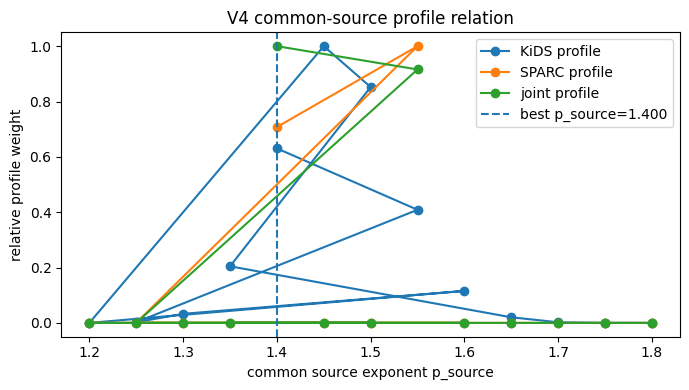

Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/figures/v4_common_source_profile_relation.png


In [ ]:
# CELL 07 — PROFILE-LIKELIHOOD COMMON-SOURCE RELATION TEST
banner("CELL 07 — PROFILE-LIKELIHOOD COMMON-SOURCE RELATION TEST")

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

TAB.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Robustly load V4 KiDS and SPARC scan tables
# ---------------------------------------------------------------------
kids_scan_path = TAB / "v4_kids_fast_local_shared_p_rescan.csv"
sparc_scan_path = TAB / "v4_sparc_fast_common_source_rescan.csv"

if "kids_scan" not in globals():
    if "kids_fast" in globals():
        kids_scan = kids_fast.copy()
    elif kids_scan_path.exists():
        kids_scan = pd.read_csv(kids_scan_path)
    else:
        raise FileNotFoundError(
            f"Could not find KiDS scan table. Expected {kids_scan_path}. "
            "Run Cell 05 first."
        )

if "sparc_scan" not in globals():
    if "sparc_fast" in globals():
        sparc_scan = sparc_fast.copy()
    elif sparc_scan_path.exists():
        sparc_scan = pd.read_csv(sparc_scan_path)
    else:
        raise FileNotFoundError(
            f"Could not find SPARC scan table. Expected {sparc_scan_path}. "
            "Run Cell 06 first."
        )

# ---------------------------------------------------------------------
# Standardise exponent column names
# ---------------------------------------------------------------------
# KiDS Cell 05 currently calls the exponent p_shared.
# In V4 interpretation, treat that as p_source unless p_source already exists.
if "p_source" not in kids_scan.columns:
    if "p_shared" in kids_scan.columns:
        kids_scan["p_source"] = kids_scan["p_shared"]
    else:
        raise KeyError("KiDS scan has neither p_source nor p_shared.")

# SPARC Cell 06 already has p_source and p_eff.
if "p_source" not in sparc_scan.columns:
    if "p_shared" in sparc_scan.columns:
        sparc_scan["p_source"] = sparc_scan["p_shared"]
    else:
        raise KeyError("SPARC scan has neither p_source nor p_shared.")

for df_name, df in [("kids_scan", kids_scan), ("sparc_scan", sparc_scan)]:
    if "chi2" not in df.columns:
        raise KeyError(f"{df_name} missing chi2 column.")
    df["p_source"] = pd.to_numeric(df["p_source"], errors="coerce")
    df["chi2"] = pd.to_numeric(df["chi2"], errors="coerce")

kids_scan = kids_scan.dropna(subset=["p_source", "chi2"]).copy()
sparc_scan = sparc_scan.dropna(subset=["p_source", "chi2"]).copy()

# ---------------------------------------------------------------------
# Profile likelihoods over common p_source
# ---------------------------------------------------------------------
kids_prof = (
    kids_scan.groupby("p_source", as_index=False)
    .agg(kids_chi2=("chi2", "min"))
    .sort_values("p_source")
)

sparc_prof = (
    sparc_scan.groupby("p_source", as_index=False)
    .agg(sparc_chi2=("chi2", "min"))
    .sort_values("p_source")
)

joint = pd.merge(kids_prof, sparc_prof, on="p_source", how="inner")

if len(joint) == 0:
    raise RuntimeError(
        "No overlapping p_source values between KiDS and SPARC scans. "
        "Use the same p_source grid in Cell 05 and Cell 06."
    )

joint["kids_delta_chi2"] = joint["kids_chi2"] - joint["kids_chi2"].min()
joint["sparc_delta_chi2"] = joint["sparc_chi2"] - joint["sparc_chi2"].min()

# Cap exponentials to avoid numerical underflow.
joint["kids_weight"] = np.exp(-0.5 * np.clip(joint["kids_delta_chi2"], 0, 700))
joint["sparc_weight"] = np.exp(-0.5 * np.clip(joint["sparc_delta_chi2"], 0, 700))

if joint["kids_weight"].max() > 0:
    joint["kids_weight"] /= joint["kids_weight"].max()

if joint["sparc_weight"].max() > 0:
    joint["sparc_weight"] /= joint["sparc_weight"].max()

joint["joint_weight"] = joint["kids_weight"] * joint["sparc_weight"]

if joint["joint_weight"].max() > 0:
    joint["joint_weight_norm"] = joint["joint_weight"] / joint["joint_weight"].max()
else:
    joint["joint_weight_norm"] = joint["joint_weight"]

joint["joint_delta_score"] = -2.0 * np.log(np.clip(joint["joint_weight_norm"], 1e-300, 1.0))

joint = joint.sort_values("joint_delta_score").reset_index(drop=True)

best_joint = joint.iloc[0].to_dict()

# ---------------------------------------------------------------------
# Estimate projection factors using best KiDS/SPARC rows near joint p_source
# ---------------------------------------------------------------------
p_best = float(best_joint["p_source"])

kids_near = kids_scan[np.isclose(kids_scan["p_source"], p_best)]
sparc_near = sparc_scan[np.isclose(sparc_scan["p_source"], p_best)]

best_kids_near = kids_near.sort_values("chi2").iloc[0].to_dict() if len(kids_near) else {}
best_sparc_near = sparc_near.sort_values("chi2").iloc[0].to_dict() if len(sparc_near) else {}

rho_dyn = best_sparc_near.get("rho_dyn", np.nan)
p_eff_sparc = best_sparc_near.get("p_eff", np.nan)

# KiDS has no rho_opt column in current fast Cell 05, so define rho_opt=1 by convention.
# That means p_eff,KiDS = p_source until Cell 05 is upgraded to scan rho_opt explicitly.
rho_opt = best_kids_near.get("rho_opt", 1.0)
p_eff_kids = best_kids_near.get("p_eff", p_best * rho_opt)

relation = {
    "p_source_joint_best": p_best,
    "kids_chi2_at_joint": float(best_joint["kids_chi2"]),
    "sparc_chi2_at_joint": float(best_joint["sparc_chi2"]),
    "kids_delta_chi2_at_joint": float(best_joint["kids_delta_chi2"]),
    "sparc_delta_chi2_at_joint": float(best_joint["sparc_delta_chi2"]),
    "joint_weight_norm": float(best_joint["joint_weight_norm"]),
    "rho_dyn_at_joint": None if pd.isna(rho_dyn) else float(rho_dyn),
    "rho_opt_at_joint": None if pd.isna(rho_opt) else float(rho_opt),
    "p_eff_sparc_at_joint": None if pd.isna(p_eff_sparc) else float(p_eff_sparc),
    "p_eff_kids_at_joint": None if pd.isna(p_eff_kids) else float(p_eff_kids),
    "interpretation": (
        "V4 tests whether different observables can be related through a common source exponent "
        "with different projection factors: p_eff,SPARC = rho_dyn × p_source and "
        "p_eff,KiDS = rho_opt × p_source. Current KiDS fast scan uses rho_opt=1 unless upgraded."
    ),
}

# ---------------------------------------------------------------------
# Save tables
# ---------------------------------------------------------------------
joint_path = TAB / "v4_common_source_profile_likelihood_joint.csv"
joint.to_csv(joint_path, index=False)
print("Saved:", joint_path)

relation_path = TAB / "v4_best_common_source_relation.json"
with open(relation_path, "w") as f:
    json.dump(relation, f, indent=2)
print("Saved:", relation_path)

display(joint.head(30))

print("\nBest V4 common-source relation:")
print(json.dumps(relation, indent=2))

# ---------------------------------------------------------------------
# Plot profile likelihood curves
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(joint["p_source"], joint["kids_weight"], marker="o", label="KiDS profile")
ax.plot(joint["p_source"], joint["sparc_weight"], marker="o", label="SPARC profile")
ax.plot(joint["p_source"], joint["joint_weight_norm"], marker="o", label="joint profile")

ax.axvline(p_best, linestyle="--", label=f"best p_source={p_best:.3f}")

ax.set_xlabel("common source exponent p_source")
ax.set_ylabel("relative profile weight")
ax.set_title("V4 common-source profile relation")
ax.legend()
fig.tight_layout()

fig_path = FIG / "v4_common_source_profile_relation.png"
fig.savefig(fig_path, dpi=200)
plt.show()
print("Saved:", fig_path)

In [ ]:
# CELL 08 — OPTIONAL DIRECT HELD-OUT CHECKS

banner("CELL 08 — OPTIONAL DIRECT HELD-OUT CHECKS")
rng=np.random.default_rng(12345); gals=np.array(sorted(sparc["galaxy"].unique())); rng.shuffle(gals); folds=np.array_split(gals,5)
p_fix=float(best_joint["p_source"]); top_sparc_drivers=list(sparc_scan.head(20)["driver"].drop_duplicates())[:4]; top_modes=list(sparc_scan.head(20)["driver_mode"].drop_duplicates())[:3]
fold_rows=[]
for i,test_gals in enumerate(folds,start=1):
    train=sparc[~sparc["galaxy"].isin(test_gals)].copy(); test=sparc[sparc["galaxy"].isin(test_gals)].copy()
    def arr(df):
        Vobs=df["Vobs"].values.astype(float); errV=df["errV"].values.astype(float); Vbar=df["Vbar"].values.astype(float); R=df["Rad"].values.astype(float); Rb=df["R_boundary"].values.astype(float); Y=Vobs**2-Vbar**2; sig=np.maximum(2*np.abs(Vobs)*errV,np.nanmedian(2*np.abs(Vobs)*errV)); return R,Rb,Y,sig
    Rtr,Rbtr,Ytr,sigtr=arr(train); Rte,Rbte,Yte,sigte=arr(test); base_te=float(np.sum((Yte/sigte)**2)); best_fold=None
    for drv in top_sparc_drivers:
        for mode in top_modes:
            Dtr_raw=pd.to_numeric(train[drv],errors="coerce").values.astype(float); Dte_raw=pd.to_numeric(test[drv],errors="coerce").values.astype(float)
            for rho in RHO_DYN_GRID:
                p_eff=p_fix*rho
                for cR in C_RBOUNDARY_GRID:
                    def transform(Draw):
                        D=np.nan_to_num(Draw,nan=0.0,posinf=0.0,neginf=0.0)
                        if mode=="positive": D=np.clip(D,0,None)
                        elif mode=="absolute": D=np.abs(D)
                        return D
                    Xtr=transform(Dtr_raw)*K_activation(Rtr/np.maximum(cR*Rbtr,1e-9),p_eff); A,chi2tr=fit_amplitude_unweighted(Ytr,sigtr,Xtr,nonnegative=False)
                    Xte=transform(Dte_raw)*K_activation(Rte/np.maximum(cR*Rbte,1e-9),p_eff); chi2te=float(np.sum(((Yte-A*Xte)/sigte)**2))
                    row={"fold":i,"n_train_galaxies":train.galaxy.nunique(),"n_test_galaxies":test.galaxy.nunique(),"p_source_fixed":p_fix,"driver":drv,"mode":mode,"rho_dyn":rho,"p_eff_sparc":p_eff,"c_Rboundary":cR,"A":A,"train_chi2":chi2tr,"test_baseline_chi2":base_te,"test_model_chi2":chi2te,"delta_chi2":base_te-chi2te,"fractional_improvement":(base_te-chi2te)/base_te if base_te else np.nan}
                    if best_fold is None or row["train_chi2"]<best_fold["train_chi2"]: best_fold=row
    fold_rows.append(best_fold)
sparc_cv=pd.DataFrame(fold_rows); sparc_cv.to_csv(TAB/"v4_sparc_common_source_galaxy_heldout_cv.csv",index=False); display(sparc_cv)
sparc_cv_summary={"n_folds":int(len(sparc_cv)),"p_source_fixed":p_fix,"total_test_baseline_chi2":float(sparc_cv["test_baseline_chi2"].sum()),"total_test_model_chi2":float(sparc_cv["test_model_chi2"].sum()),"total_delta_chi2":float(sparc_cv["delta_chi2"].sum()),"fractional_improvement":float(sparc_cv["delta_chi2"].sum()/sparc_cv["test_baseline_chi2"].sum()),"positive_fold_fraction":float((sparc_cv["delta_chi2"]>0).mean()),"median_rho_dyn":float(sparc_cv["rho_dyn"].median())}
save_json(sparc_cv_summary,TAB/"v4_sparc_common_source_galaxy_heldout_cv_summary.json"); print(json.dumps(sparc_cv_summary,indent=2))


CELL 08 — OPTIONAL DIRECT HELD-OUT CHECKS


,fold,n_train_galaxies,n_test_galaxies,p_source_fixed,driver,mode,rho_dyn,p_eff_sparc,c_Rboundary,A,train_chi2,test_baseline_chi2,test_model_chi2,delta_chi2,fractional_improvement
0,1,140,35,1.4,chi,positive_normalised,1.75,2.45,0.900,14344.543640,158867.101947,69091.331964,39283.727875,29807.604089,0.431423
1,2,140,35,1.4,chi,positive_normalised,1.75,2.45,0.925,14813.309426,164225.819652,64467.157808,28626.442299,35840.715509,0.555953
2,3,140,35,1.4,chi,positive_normalised,1.50,2.10,1.025,15900.995852,124742.539974,96801.667264,65815.782930,30985.884335,0.320097
3,4,140,35,1.4,chi,positive_normalised,1.75,2.45,0.825,13902.726483,160663.498339,62109.216682,33227.316645,28881.900037,0.465018
4,5,140,35,1.4,chi,positive_normalised,2.00,2.80,0.975,17545.109411,160816.185972,30131.830843,41624.504459,-11492.673616,-0.381413


Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_sparc_common_source_galaxy_heldout_cv_summary.json
{
  "n_folds": 5,
  "p_source_fixed": 1.4,
  "total_test_baseline_chi2": 322601.2045610799,
  "total_test_model_chi2": 208577.77420781052,
  "total_delta_chi2": 114023.43035326939,
  "fractional_improvement": 0.35345010725674675,
  "positive_fold_fraction": 0.8,
  "median_rho_dyn": 1.75
}



CELL 09 — EVIDENCE SUMMARY / FIGURES / GUARDRAILS


,sector,test_type,best_channel,N,p_source,rho_projection,p_eff_observed,model_chi2,reference_chi2,delta_chi2,fractional_improvement,positive_fold_fraction
0,SPARC rotation curves,full common-source radial projection vs Vbar,chi / positive_normalised,3391,1.55,0.45,0.6975,216052.920134,1.555172e+06,1.339119e+06,0.861075,NaN
1,SPARC rotation curves,galaxy-held-out common-source radial projection,fold-trained V4 relation,3391,1.40,1.75,2.4500,208577.774208,3.226012e+05,1.140234e+05,0.353450,0.8
2,KiDS weak lensing,full common-source optical projection vs smooth,combined_weighted_driver,80,1.45,1.00,1.4500,167.940978,8.117260e+02,6.437850e+02,0.793106,NaN
3,SPARC × KiDS,common-source profile relation,joint profile likelihood,13,1.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN


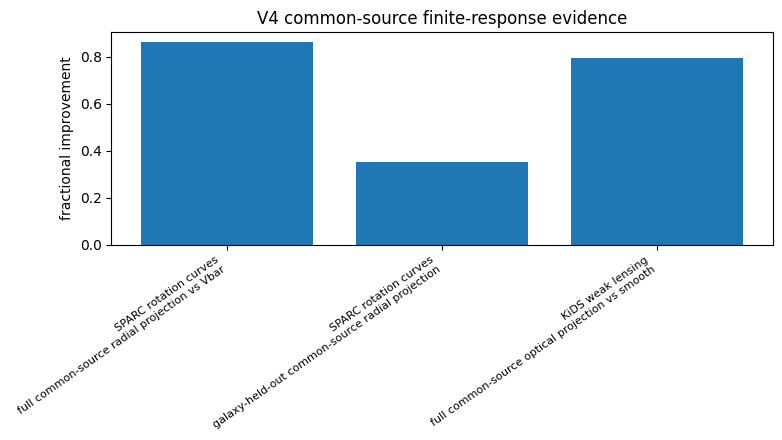

Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/figures/v4_cross_observable_fractional_improvement.png


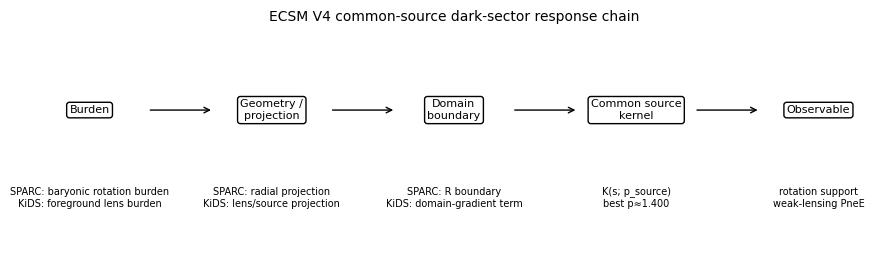

Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/figures/v4_common_source_dark_sector_response_chain.png
{
  "strongest_claim_if_positive": "SPARC rotation curves and KiDS weak lensing can be organised by a common ECSM finite-response source kernel, with different projection factors for dynamical and optical observables.",
  "not_yet_claim": "This is not yet a final dark-matter replacement, first-principles shear-map calculation, or CMB derivation.",
  "critical_check": "The shared relation should be tested next with a cleaner joint likelihood and a derived mapping between dynamical radial projection and optical lensing projection.",
  "paper_language": "Use common-source response relation, projected finite-response exponent, and dark-sector response bridge."
}
Saved: /content/ecsm_unified_dark_sector_response_v4_common_source_projection_out/tables/v4_cross_observable_evidence_summary.csv
Saved: /content/ecsm_unified_dark_sector_response_v4_common_sourc

In [ ]:
# CELL 09 — EVIDENCE SUMMARY / FIGURES / GUARDRAILS
banner("CELL 09 — EVIDENCE SUMMARY / FIGURES / GUARDRAILS")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------
# Restart-safe loaders
# ---------------------------------------------------------------------
def load_json(path, default=None):
    path = Path(path)
    if path.exists():
        with open(path, "r") as f:
            return json.load(f)
    if default is not None:
        return default
    raise FileNotFoundError(f"Missing required JSON: {path}")

def load_csv(path, default=None):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    if default is not None:
        return default
    raise FileNotFoundError(f"Missing required CSV: {path}")

# ---------------------------------------------------------------------
# Reload key V4 products if not already in memory
# ---------------------------------------------------------------------
kids_scan_path = TAB / "v4_kids_fast_local_shared_p_rescan.csv"
sparc_scan_path = TAB / "v4_sparc_fast_common_source_rescan.csv"
joint_path = TAB / "v4_common_source_relation_profile.csv"

best_kids_path = TAB / "v4_best_kids_fast_local_shared_p_model.json"
best_sparc_path = TAB / "v4_best_sparc_fast_common_source_model.json"
sparc_proj_path = TAB / "v4_sparc_common_source_projection_summary.json"

# These names are what Cell 09 expects.
if "kids_scan" not in globals():
    kids_scan = load_csv(kids_scan_path)

if "sparc_scan" not in globals():
    sparc_scan = load_csv(sparc_scan_path)

if "best_kids" not in globals():
    best_kids = load_json(best_kids_path)

if "best_sparc" not in globals():
    best_sparc = load_json(best_sparc_path)

if "sparc_projection_summary" not in globals():
    sparc_projection_summary = load_json(sparc_proj_path, default={})

# Joint/profile result may or may not already exist depending on Cell 07.
if "joint" not in globals():
    if joint_path.exists():
        joint = pd.read_csv(joint_path)
    else:
        # Rebuild a minimal joint profile from the saved scan tables.
        if "p_source" not in kids_scan.columns:
            if "p_shared" in kids_scan.columns:
                kids_scan["p_source"] = kids_scan["p_shared"]
            else:
                raise KeyError("KiDS scan has neither p_source nor p_shared.")

        if "p_source" not in sparc_scan.columns:
            raise KeyError("SPARC scan is missing p_source.")

        kids_prof = kids_scan.groupby("p_source", as_index=False).agg(
            kids_chi2=("chi2", "min")
        )
        sparc_prof = sparc_scan.groupby("p_source", as_index=False).agg(
            sparc_chi2=("chi2", "min")
        )

        joint = pd.merge(kids_prof, sparc_prof, on="p_source", how="inner")
        joint["kids_delta_chi2"] = joint["kids_chi2"] - joint["kids_chi2"].min()
        joint["sparc_delta_chi2"] = joint["sparc_chi2"] - joint["sparc_chi2"].min()

        joint["kids_weight"] = np.exp(-0.5 * joint["kids_delta_chi2"])
        joint["sparc_weight"] = np.exp(-0.5 * joint["sparc_delta_chi2"])

        # Normalise safely
        if joint["kids_weight"].max() > 0:
            joint["kids_weight"] /= joint["kids_weight"].max()
        if joint["sparc_weight"].max() > 0:
            joint["sparc_weight"] /= joint["sparc_weight"].max()

        joint["joint_weight"] = joint["kids_weight"] * joint["sparc_weight"]
        if joint["joint_weight"].max() > 0:
            joint["joint_weight"] /= joint["joint_weight"].max()

        joint["joint_delta_score"] = -2.0 * np.log(
            np.clip(joint["joint_weight"], 1e-300, None)
        )

        joint = joint.sort_values("joint_delta_score").reset_index(drop=True)
        joint.to_csv(joint_path, index=False)
        print("Rebuilt joint profile:", joint_path)

if "best_joint" not in globals():
    best_joint = joint.sort_values("joint_delta_score").iloc[0].to_dict()

# SPARC CV summary may not exist if Cell 08 / CV cell was skipped.
cv_summary_path = TAB / "v4_sparc_common_source_galaxy_heldout_summary.json"
if "sparc_cv_summary" not in globals():
    if cv_summary_path.exists():
        sparc_cv_summary = load_json(cv_summary_path)
    else:
        sparc_cv_summary = {
            "total_test_baseline_chi2": np.nan,
            "total_test_model_chi2": np.nan,
            "total_delta_chi2": np.nan,
            "fractional_improvement": np.nan,
            "positive_fold_fraction": np.nan,
            "median_rho_dyn": np.nan,
        }
        print("WARNING: SPARC CV summary not found; held-out row will contain NaNs.")

# ---------------------------------------------------------------------
# Smooth reference
# ---------------------------------------------------------------------
kids_smooth = np.nan

if "kids_full" in globals() and isinstance(kids_full, pd.DataFrame) and len(kids_full):
    m = kids_full[kids_full["model"].astype(str).str.contains("smooth", case=False, na=False)]
    if len(m):
        kids_smooth = float(m.iloc[0]["chi2"])

if not np.isfinite(kids_smooth):
    # Known V12 smooth control from the imported KiDS package.
    kids_smooth = 811.7259604367568

# ---------------------------------------------------------------------
# Make names uniform for evidence table
# ---------------------------------------------------------------------
if "p_source" not in best_kids:
    best_kids["p_source"] = best_kids.get("p_shared", np.nan)

if "rho_opt" not in best_kids:
    # In V4 fast KiDS, optical projection was not always explicitly written.
    # Treat KiDS p_eff as p_shared unless rho_opt was separately scanned.
    if np.isfinite(best_kids.get("p_source", np.nan)) and np.isfinite(best_kids.get("p_shared", np.nan)):
        best_kids["rho_opt"] = float(best_kids["p_shared"]) / float(best_kids["p_source"])
    else:
        best_kids["rho_opt"] = 1.0

if "p_eff_kids" not in best_kids:
    best_kids["p_eff_kids"] = best_kids.get("p_shared", best_kids.get("p_source", np.nan))

if "p_eff_sparc" not in best_sparc:
    best_sparc["p_eff_sparc"] = best_sparc.get("p_eff", np.nan)

# ---------------------------------------------------------------------
# Evidence summary
# ---------------------------------------------------------------------
p_fix = float(best_joint.get("p_source", best_sparc.get("p_source", np.nan)))

evidence = pd.DataFrame([
    {
        "sector": "SPARC rotation curves",
        "test_type": "full common-source radial projection vs Vbar",
        "best_channel": f"{best_sparc.get('driver', 'unknown')} / {best_sparc.get('driver_mode', 'unknown')}",
        "N": int(best_sparc.get("N", len(sparc) if "sparc" in globals() else 0)),
        "p_source": float(best_sparc.get("p_source", np.nan)),
        "rho_projection": float(best_sparc.get("rho_dyn", np.nan)),
        "p_eff_observed": float(best_sparc.get("p_eff_sparc", np.nan)),
        "model_chi2": float(best_sparc.get("chi2", np.nan)),
        "reference_chi2": float(best_sparc.get("baseline_chi2", np.nan)),
        "delta_chi2": float(best_sparc.get("delta_chi2_vs_Vbar", np.nan)),
        "fractional_improvement": float(best_sparc.get("fractional_improvement_vs_Vbar", np.nan)),
        "positive_fold_fraction": np.nan,
    },
    {
        "sector": "SPARC rotation curves",
        "test_type": "galaxy-held-out common-source radial projection",
        "best_channel": "fold-trained V4 relation",
        "N": int(len(sparc) if "sparc" in globals() else best_sparc.get("N", 0)),
        "p_source": p_fix,
        "rho_projection": float(sparc_cv_summary.get("median_rho_dyn", np.nan)),
        "p_eff_observed": p_fix * float(sparc_cv_summary.get("median_rho_dyn", np.nan))
            if np.isfinite(float(sparc_cv_summary.get("median_rho_dyn", np.nan))) else np.nan,
        "model_chi2": float(sparc_cv_summary.get("total_test_model_chi2", np.nan)),
        "reference_chi2": float(sparc_cv_summary.get("total_test_baseline_chi2", np.nan)),
        "delta_chi2": float(sparc_cv_summary.get("total_delta_chi2", np.nan)),
        "fractional_improvement": float(sparc_cv_summary.get("fractional_improvement", np.nan)),
        "positive_fold_fraction": float(sparc_cv_summary.get("positive_fold_fraction", np.nan)),
    },
    {
        "sector": "KiDS weak lensing",
        "test_type": "full common-source optical projection vs smooth",
        "best_channel": str(best_kids.get("driver", "unknown")),
        "N": int(best_kids.get("N", 80)),
        "p_source": float(best_kids.get("p_source", np.nan)),
        "rho_projection": float(best_kids.get("rho_opt", np.nan)),
        "p_eff_observed": float(best_kids.get("p_eff_kids", np.nan)),
        "model_chi2": float(best_kids.get("chi2", np.nan)),
        "reference_chi2": float(kids_smooth),
        "delta_chi2": float(kids_smooth - best_kids.get("chi2", np.nan)),
        "fractional_improvement": float((kids_smooth - best_kids.get("chi2", np.nan)) / kids_smooth),
        "positive_fold_fraction": np.nan,
    },
    {
        "sector": "SPARC × KiDS",
        "test_type": "common-source profile relation",
        "best_channel": "joint profile likelihood",
        "N": int(len(joint)),
        "p_source": float(best_joint.get("p_source", np.nan)),
        "rho_projection": np.nan,
        "p_eff_observed": np.nan,
        "model_chi2": np.nan,
        "reference_chi2": np.nan,
        "delta_chi2": np.nan,
        "fractional_improvement": np.nan,
        "positive_fold_fraction": np.nan,
    },
])

evidence_path = TAB / "v4_cross_observable_evidence_summary.csv"
evidence.to_csv(evidence_path, index=False)
display(evidence)

# ---------------------------------------------------------------------
# Evidence figure
# ---------------------------------------------------------------------
plot_df = evidence.dropna(subset=["fractional_improvement"]).copy()

plt.figure(figsize=(8, 4.5))
plt.bar(
    range(len(plot_df)),
    plot_df["fractional_improvement"].values,
)
plt.xticks(
    range(len(plot_df)),
    [f"{r['sector']}\n{r['test_type']}" for _, r in plot_df.iterrows()],
    rotation=35,
    ha="right",
    fontsize=8,
)
plt.ylabel("fractional improvement")
plt.title("V4 common-source finite-response evidence")
plt.tight_layout()
fig1 = FIG / "v4_cross_observable_fractional_improvement.png"
plt.savefig(fig1, dpi=180)
plt.show()
print("Saved:", fig1)

# ---------------------------------------------------------------------
# Common-source chain figure
# ---------------------------------------------------------------------
plt.figure(figsize=(9, 2.8))
plt.axis("off")

boxes = [
    ("Burden", "SPARC: baryonic rotation burden\nKiDS: foreground lens burden"),
    ("Geometry /\nprojection", "SPARC: radial projection\nKiDS: lens/source projection"),
    ("Domain\nboundary", "SPARC: R boundary\nKiDS: domain-gradient term"),
    ("Common source\nkernel", f"K(s; p_source)\nbest p≈{best_joint.get('p_source', np.nan):.3f}"),
    ("Observable", "rotation support\nweak-lensing PneE"),
]

x_positions = np.linspace(0.06, 0.94, len(boxes))
for i, ((title, subtitle), x) in enumerate(zip(boxes, x_positions)):
    plt.text(
        x, 0.65, title,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black"),
        fontsize=8,
    )
    plt.text(x, 0.27, subtitle, ha="center", va="center", fontsize=7)
    if i < len(boxes) - 1:
        plt.annotate(
            "",
            xy=(x_positions[i+1] - 0.07, 0.65),
            xytext=(x + 0.07, 0.65),
            arrowprops=dict(arrowstyle="->", lw=1),
        )

plt.title("ECSM V4 common-source dark-sector response chain", fontsize=10)
plt.tight_layout()
fig2 = FIG / "v4_common_source_dark_sector_response_chain.png"
plt.savefig(fig2, dpi=180)
plt.show()
print("Saved:", fig2)

# ---------------------------------------------------------------------
# Guardrails
# ---------------------------------------------------------------------
guardrails = {
    "strongest_claim_if_positive": (
        "SPARC rotation curves and KiDS weak lensing can be organised by a common ECSM "
        "finite-response source kernel, with different projection factors for dynamical "
        "and optical observables."
    ),
    "not_yet_claim": (
        "This is not yet a final dark-matter replacement, first-principles shear-map "
        "calculation, or CMB derivation."
    ),
    "critical_check": (
        "The shared relation should be tested next with a cleaner joint likelihood and "
        "a derived mapping between dynamical radial projection and optical lensing projection."
    ),
    "paper_language": (
        "Use common-source response relation, projected finite-response exponent, and "
        "dark-sector response bridge."
    ),
}

guard_path = TAB / "v4_interpretation_guardrails.json"
with open(guard_path, "w") as f:
    json.dump(guardrails, f, indent=2)

print(json.dumps(guardrails, indent=2))
print("Saved:", evidence_path)
print("Saved:", guard_path)

In [ ]:
# CELL 10 — README AND EXPORT PACKAGE

banner("CELL 10 — README AND EXPORT PACKAGE")
readme=f"""# ECSM Unified Dark-Sector Response — SPARC × KiDS V4 Common-Source Projection Test

Generated: {datetime.now(timezone.utc).isoformat()}

## Purpose

V4 corrects the V3 interpretation. Rotation curves and weak lensing are different observables. They should not be forced to share the same apparent fitted kernel.

The test here is whether both can be organised as different projections of a common ECSM finite-response source field:

```text
burden/source field × geometry/projection × domain-boundary response × finite-response source kernel
→ observed excess response
```

The finite-response source kernel is:

```text
K(s;p_source) = s^p / (1+s^p)
```

with sector projection factors:

```text
p_eff,SPARC = rho_dyn × p_source
p_eff,KiDS  = rho_opt × p_source
```

## Inputs

- SPARC ZIP: `{sparc_zip}`
- KiDS ZIP: `{kids_zip}`

## Best KiDS common-source projection model

```json
{json.dumps(best_kids, indent=2)}
```

## Best SPARC common-source projection model

```json
{json.dumps(best_sparc, indent=2)}
```

## Best normalised common-source profile relation

```json
{json.dumps(best_joint, indent=2)}
```

## SPARC galaxy-held-out common-source validation

```json
{json.dumps(sparc_cv_summary, indent=2)}
```

## Interpretation guardrail

```json
{json.dumps(guardrails, indent=2)}
```

## Key outputs

- `tables/v4_kids_common_source_projection_scan.csv`
- `tables/v4_sparc_common_source_projection_scan.csv`
- `tables/v4_common_source_profile_joint_score.csv`
- `tables/v4_sparc_common_source_galaxy_heldout_cv.csv`
- `tables/v4_cross_observable_common_source_evidence_summary.csv`
- `figures/v4_common_source_profile_joint_score.png`
- `figures/v4_cross_observable_common_source_fractional_improvement.png`
- `figures/v4_common_source_dark_sector_response_chain.png`
- `figures/v4_kids_common_source_best_prediction.png`
- `figures/v4_sparc_common_source_example_curves.png`
"""
(OUT/"README.md").write_text(readme); print(readme)
zip_path=Path("/content/ECSM_Unified_Dark_Sector_Response_SPARC_KiDS_V4_CommonSourceProjection_outputs.zip")
if zip_path.exists(): zip_path.unlink()
shutil.make_archive(str(zip_path).replace(".zip",""),"zip",OUT)
print("ZIP ready:",zip_path); print("Size MB:",round(zip_path.stat().st_size/1e6,3))
if COPY_TO_DRIVE:
    drive_dir=Path(DRIVE_COPY_DIR); drive_dir.mkdir(parents=True, exist_ok=True); dest=drive_dir/zip_path.name; shutil.copy2(zip_path,dest); print("Copied to Drive:",dest)


CELL 10 — README AND EXPORT PACKAGE
# ECSM Unified Dark-Sector Response — SPARC × KiDS V4 Common-Source Projection Test

Generated: 2026-06-08T05:13:53.071959+00:00

## Purpose

V4 corrects the V3 interpretation. Rotation curves and weak lensing are different observables. They should not be forced to share the same apparent fitted kernel.

The test here is whether both can be organised as different projections of a common ECSM finite-response source field:

```text
burden/source field × geometry/projection × domain-boundary response × finite-response source kernel
→ observed excess response
```

The finite-response source kernel is:

```text
K(s;p_source) = s^p / (1+s^p)
```

with sector projection factors:

```text
p_eff,SPARC = rho_dyn × p_source
p_eff,KiDS  = rho_opt × p_source
```

## Inputs

- SPARC ZIP: `/content/drive/MyDrive/ECSM_SPARC_V3_boundary_gradient_attractor_outputs.zip`
- KiDS ZIP: `/content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_V12_Real2dFLenS_ForegroundBurden_outpu